## 5. Baseline Models before Class Imbalance Handling-------------------------------------

DECISION TREE

In [ ]:
# Create Pipeline for decision tree
dt_p = Pipeline([
    ("preprocess", preprocess),
    ("dtclf", DecisionTreeClassifier(random_state=42))
])

# Create Gridsearch
dt_grid = GridSearchCV(
    dt_p,
    param_grid={
        "dtclf__max_depth": [None, 10, 20],
        "dtclf__min_samples_split": [2, 5, 10]
    },
    scoring=scoring, cv=cv, n_jobs=-1
)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
val_scores = [] # Initialize val_scores

# load decision tree model without SMOTE
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_val_pred = dt_best.predict(X_val)

# classification
print('Decision Tree Accuracy:', accuracy_score(y_val, y_val_pred))
print('Classification Report:')
print(classification_report(y_val, y_val_pred))

# confusion matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, y_val_pred))

Decision Tree Accuracy: 0.930165314148516
Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.93      0.93     42368
           2       0.94      0.94      0.94     56660
           3       0.91      0.92      0.92      7151
           4       0.82      0.83      0.82       549
           5       0.79      0.82      0.81      1899
           6       0.86      0.84      0.85      3474
           7       0.94      0.95      0.94      4102

    accuracy                           0.93    116203
   macro avg       0.88      0.89      0.89    116203
weighted avg       0.93      0.93      0.93    116203


Confusion Matrix:
[[39367  2745     3     0    44     7   202]
 [ 2649 53306   199     1   331   136    38]
 [    3   164  6583    68    25   307     1]
 [    0     0    73   454     0    22     0]
 [   43   268    23     0  1559     6     0]
 [   11   134   351    32    11  2935     0]
 [  202    15     0     0     1     0  3884]]


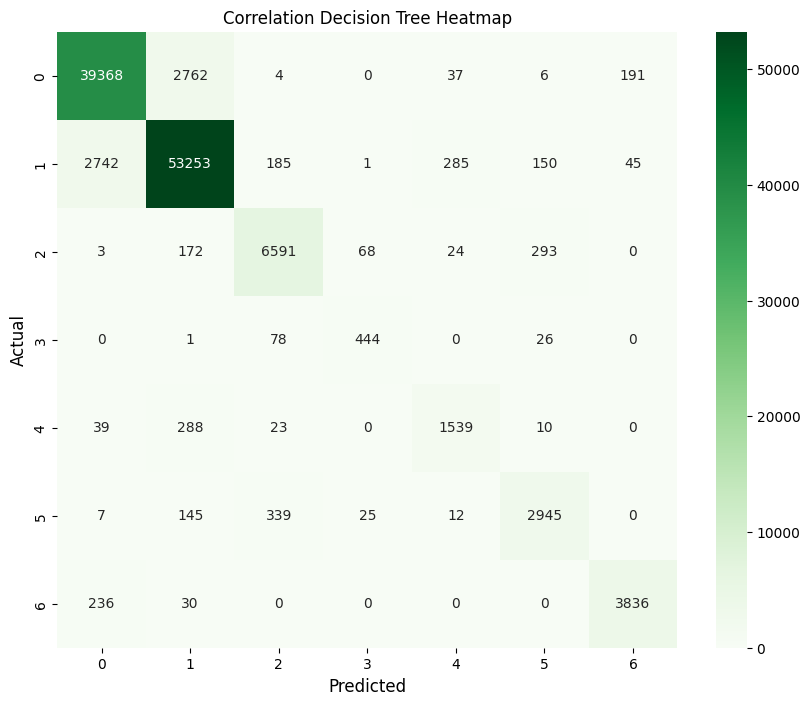

In [ ]:
# visualize decision tree model correlation using heatmap
dt_y_pred = dt_best.predict(X_test)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, dt_y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Correlation Decision Tree Heatmap', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

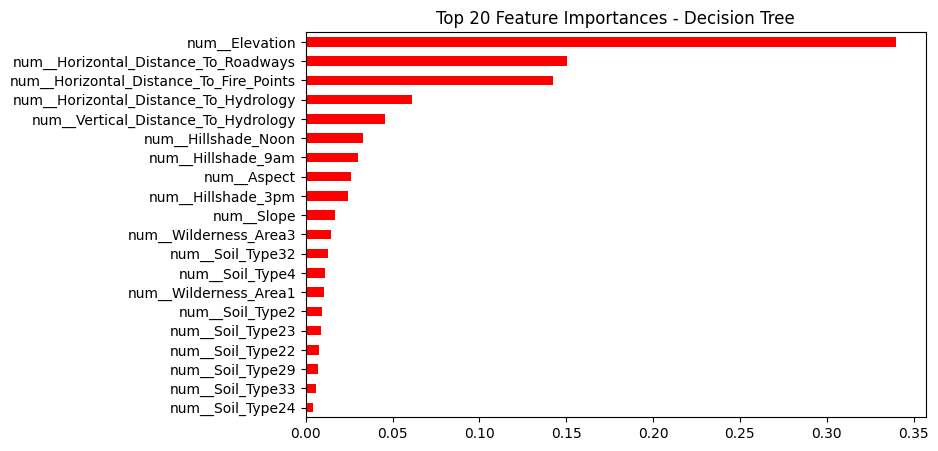

In [ ]:
# Feature Importance
importances = dt_best.named_steps['dtclf'].feature_importances_
feat_names = dt_best.named_steps['preprocess'].get_feature_names_out()

fi = pd.Series(importances, index=feat_names).sort_values(ascending=False)
fi.head(20).plot(kind='barh', figsize=(8,5), color='red')
plt.title("Top 20 Feature Importances - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

RANDOM FOREST

In [ ]:
# create pipeline
rf_base = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(random_state=42))
])

rf_grid = GridSearchCV(
    rf_base,
    param_grid={
        "clf__n_estimators": [300, 500],
        "clf__max_depth": [None, 10, 20]
    },
    scoring=scoring, cv=cv, n_jobs=1
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
rf_val_scores = [] # Initialize val_scores

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
# load random forest model without SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_best.predict(X_val)

# Classification
print('Random Forest Accuracy:', accuracy_score(y_val, rf_y_pred))
print('Classification Report:')
print(classification_report(y_val, rf_y_pred))

# Confusion Matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, rf_y_pred))

Random Forest Accuracy: 0.9483317986626851
Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.93      0.95     42368
           2       0.94      0.97      0.96     56660
           3       0.93      0.96      0.95      7151
           4       0.91      0.85      0.88       549
           5       0.92      0.76      0.83      1899
           6       0.92      0.89      0.90      3474
           7       0.97      0.94      0.96      4102

    accuracy                           0.95    116203
   macro avg       0.94      0.90      0.92    116203
weighted avg       0.95      0.95      0.95    116203


Confusion Matrix:
[[39552  2709     2     0    12     9    84]
 [ 1377 54957   131     1   101    73    20]
 [    1   111  6848    28     5   158     0]
 [    0     0    66   465     0    18     0]
 [   27   404    29     0  1435     4     0]
 [    6   103   257    18     4  3086     0]
 [  228    17     0     0     1     0  3856]]


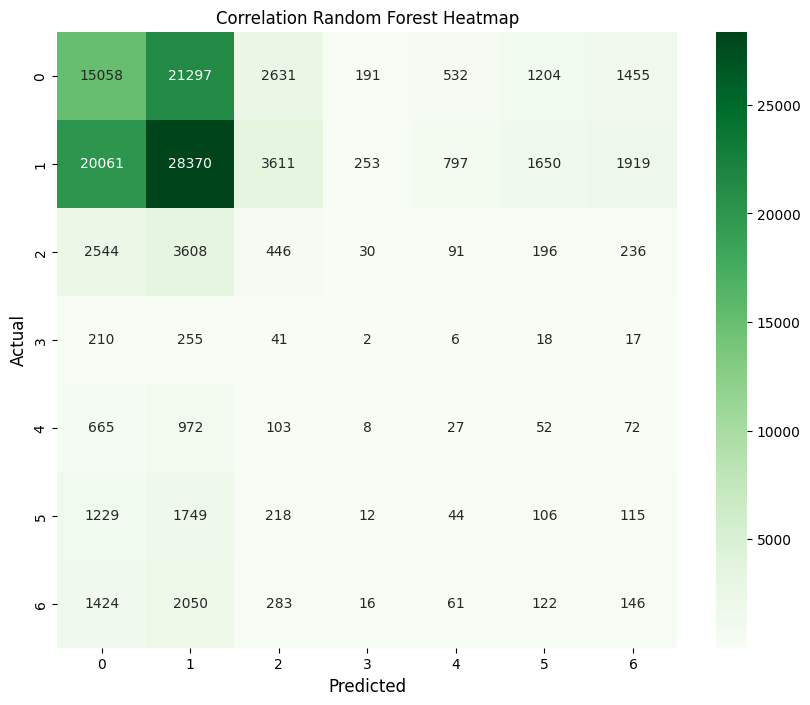

In [ ]:
# visualize random forest model correlation using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, rf_y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Correlation Random Forest Heatmap', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

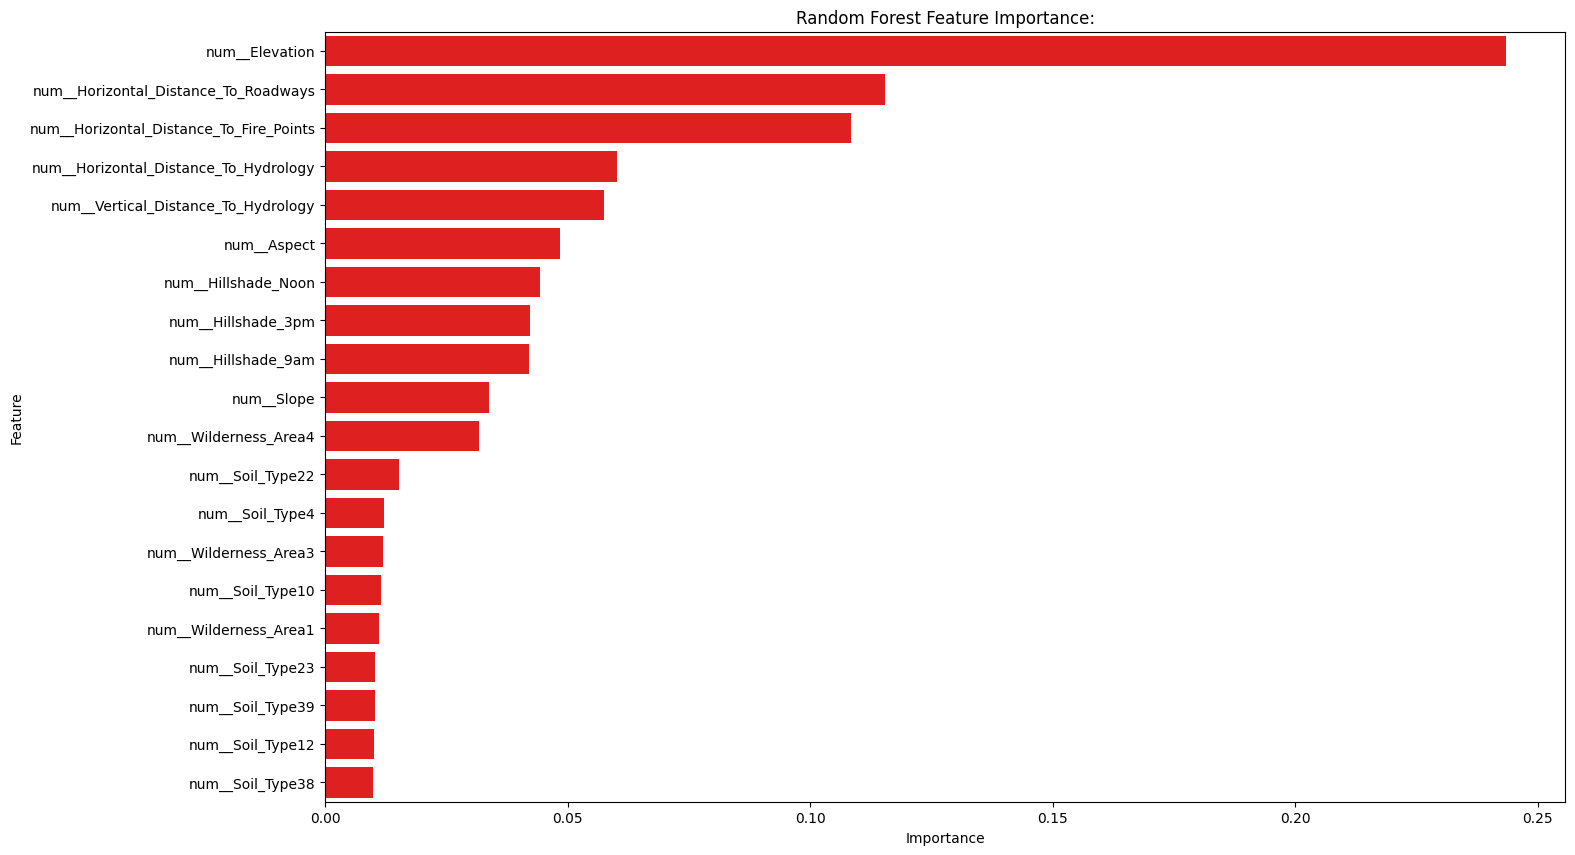

In [ ]:
# Feature Importance of Random Forest Model
importances = rf_best.named_steps['clf'].feature_importances_
feat_names = rf_best.named_steps['prep'].get_feature_names_out()

fi = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(16, 10))
sns.barplot(x=fi.head(20).values, y=fi.head(20).index, color='red')
plt.title('Random Forest Feature Importance:')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

XGBOOST

In [ ]:
num_classes = y.nunique()

# Adjust target variable to be zero-indexed for XGBoost
y_train_adjusted = y_train - 1
y_val_adjusted = y_val - 1

xgb_base = Pipeline([
    ("prep", preprocess),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        num_class=num_classes,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42
    ))
])
xgb_base_grid = GridSearchCV(
    xgb_base,
    param_grid={
        "clf__n_estimators": [300, 500],
        "clf__max_depth": [4, 6, 8],
        "clf__learning_rate": [0.05, 0.1]
    },
    scoring=scoring, cv=cv, n_jobs=-1
)
xgb_base_grid.fit(X_train, y_train_adjusted) # Use adjusted y_train
xgb_base_best = xgb_base_grid.best_estimator_
# val_scores.append(("XGB (baseline)", evaluate_split("XGB (baseline) — VALIDATION", xgb_base_best, X_val, y_val)))

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

w_train = compute_sample_weight(class_weight="balanced", y=y_train_adjusted)

xgb_w = Pipeline([
    ("prep", preprocess),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        num_class=num_classes,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42
    ))
])

xgb_w_grid = GridSearchCV(
    xgb_w,
    param_grid={
        "clf__n_estimators": [300, 500],
        "clf__max_depth": [4, 6, 8],
        "clf__learning_rate": [0.05, 0.1]
    },
    scoring="f1_macro", cv=cv, n_jobs=-1
)

# Some sklearn versions don’t pass sample_weight through GridSearchCV
# apply estimator use!
try:
    xgb_w_grid.fit(X_train, y_train_adjusted, **{"clf__sample_weight": w_train})
    xgb_w_best = xgb_w_grid.best_estimator_
except TypeError:
    # fit grid without weights, then refit best with weights
    xgb_w_grid.fit(X_train, y_train_adjusted)
    xgb_w_best = xgb_w_grid.best_estimator_
    xgb_w_best.fit(X_train, y_train_adjusted, **{"clf__sample_weight": w_train})

# Validation evaluation
y_val_pred_adjusted = xgb_w_best.predict(X_val)
# Convert predictions back to original class labels 1-7 for evaluation against original y_val
y_val_pred = y_val_pred_adjusted + 1

print("\nXGB (weighted) — VALIDATION ONLY")
print(classification_report(y_val, y_val_pred, digits=3))
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))


XGB (weighted) — VALIDATION ONLY
              precision    recall  f1-score   support

           1      0.910     0.919     0.915     42368
           2      0.942     0.911     0.926     56660
           3      0.940     0.957     0.948      7151
           4      0.885     0.927     0.906       549
           5      0.694     0.953     0.803      1899
           6      0.864     0.953     0.906      3474
           7      0.935     0.985     0.959      4102

    accuracy                          0.921    116203
   macro avg      0.881     0.943     0.909    116203
weighted avg      0.923     0.921     0.922    116203

Accuracy: 0.9213359379706204
Confusion Matrix:
 [[38930  3080     2     0   111    15   230]
 [ 3775 51622   273     1   665   272    52]
 [    0    32  6841    44    16   218     0]
 [    0     0    28   509     0    12     0]
 [    3    64    18     0  1809     5     0]
 [    3    17   118    21     6  3309     0]
 [   53     6     0     0     1     0  4042]]


In [ ]:
# XGBOOST MODEL
# y predict for xgboost
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train_adjusted)
xgb_y_pred = xgb.predict(X_test)
xgb_y_pred = xgb_y_pred + 1
print(np.unique(xgb_y_pred))

# classification
print('\nXGBoost Accuracy:', accuracy_score(y_val, xgb_y_pred))
print('Classification Report:')
print(classification_report(y_val, xgb_y_pred))

# confusion matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, xgb_y_pred))

[1 2 3 4 5 6 7]

XGBoost Accuracy: 0.3816338648744008
Classification Report:
              precision    recall  f1-score   support

           1       0.37      0.35      0.36     42368
           2       0.49      0.50      0.50     56660
           3       0.06      0.06      0.06      7151
           4       0.00      0.00      0.00       549
           5       0.02      0.01      0.02      1899
           6       0.03      0.03      0.03      3474
           7       0.04      0.04      0.04      4102

    accuracy                           0.38    116203
   macro avg       0.14      0.14      0.14    116203
weighted avg       0.38      0.38      0.38    116203


Confusion Matrix:
[[15027 21372  2674   208   489  1221  1377]
 [20083 28579  3525   237   653  1623  1960]
 [ 2459  3633   463    38    82   206   270]
 [  181   293    39     0     5     7    24]
 [  655   959   115     9    28    56    77]
 [ 1222  1789   198    21    29   101   114]
 [ 1451  2072   247    19    51   113

# 6. Class Imbalance Handling-----------------------------------

In [ ]:
# Import all neccessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# sklearn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from sklearn.utils.class_weight import compute_sample_weight
# imbalanced-learn
from imblearn.pipeline import Pipeline          # imblearn Pipeline supports SMOTE inside CV
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
# XGBoost
from xgboost import XGBClassifier

In [ ]:
# Setup shared config
# StratifiedKFold for all models because target is imbalanced
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'f1_macro'   # macro F1 is best for imbalanced multiclass
RANDOM_STATE = 42

print('All imports successful.')

All imports successful.


# CLASS IMBALANCE HANDLING - SMOTE

In [ ]:
# Helper for evaluate on validation set
def evaluate(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    print(f'\n=== {name} ===')
    print(classification_report(y_eval, y_pred, digits=3))
    print(f'Accuracy : {accuracy_score(y_eval, y_pred):.4f}')
    print(f'F1 Macro : {f1_score(y_eval, y_pred, average="macro"):.4f}')
    print('Confusion Matrix:')
    print(confusion_matrix(y_eval, y_pred))
    return f1_score(y_eval, y_pred, average='macro')

DECISION TREE

In [ ]:
# SMOTE WITH DECISION TREE
smote_dt_pipe = Pipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

smote_dt_params = {
    'smote__k_neighbors': [3, 5],
    'clf__max_depth': [10, 20, 30, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__criterion': ['gini', 'entropy'],
    'clf__class_weight': [None, 'balanced']
}

smote_dt_search = RandomizedSearchCV(
    smote_dt_pipe,
    param_distributions=smote_dt_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

smote_dt_search.fit(X_train, y_train)
smote_dt_best = smote_dt_search.best_estimator_

print('Best params (SMOTE + DT):', smote_dt_search.best_params_)
print(f'Best CV F1 Macro: {smote_dt_search.best_score_:.4f}')
evaluate('SMOTE + Decision Tree — VALIDATION', smote_dt_best, X_val, y_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params (SMOTE + DT): {'smote__k_neighbors': 5, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}
Best CV F1 Macro: 0.8808

=== SMOTE + Decision Tree — VALIDATION ===
              precision    recall  f1-score   support

           1      0.921     0.937     0.929     42368
           2      0.950     0.927     0.939     56660
           3      0.916     0.932     0.924      7151
           4      0.838     0.878     0.858       549
           5      0.764     0.858     0.808      1899
           6      0.843     0.872     0.857      3474
           7      0.928     0.957     0.942      4102

    accuracy                          0.929    116203
   macro avg      0.880     0.909     0.894    116203
weighted avg      0.930     0.929     0.929    116203

Accuracy : 0.9290
F1 Macro : 0.8938
Confusion Matrix:
[[39693  2319     5    

0.8937959270498271

RANDOM FOREST

In [ ]:
# SMOTE WITH RANDOM FOREST
# pipeline setup
smote_rf_pipe = Pipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

smote_rf_params = {
    'smote__k_neighbors': [3, 5],
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
    'clf__max_features': ['sqrt', 'log2']
}

# tuning by RandomizedSearchCV and StratifiedKFold (with cross validation)
smote_rf_search = RandomizedSearchCV(
    smote_rf_pipe,
    param_distributions=smote_rf_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

smote_rf_search.fit(X_train, y_train)
smote_rf_best = smote_rf_search.best_estimator_

print('Best params (SMOTE with RF):', smote_rf_search.best_params_)
print(f'Best CV F1 Macro: {smote_rf_search.best_score_:.4f}')
evaluate('SMOTE + Random Forest — VALIDATION', smote_rf_best, X_val, y_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params (SMOTE with RF): {'smote__k_neighbors': 3, 'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Best CV F1 Macro: 0.9209

=== SMOTE + Random Forest — VALIDATION ===
              precision    recall  f1-score   support

           1      0.959     0.941     0.950     42368
           2      0.955     0.959     0.957     56660
           3      0.937     0.958     0.947      7151
           4      0.881     0.907     0.894       549
           5      0.841     0.891     0.865      1899
           6      0.879     0.927     0.902      3474
           7      0.956     0.970     0.963      4102

    accuracy                          0.951    116203
   macro avg      0.916     0.936     0.926    116203
weighted avg      0.951     0.951     0.951    116203

Accuracy : 0.9507
F1 Macro : 0.9256
Confusion Matrix:
[[39883  2281     5     0    41    16   142]
 [ 1579 54359   208     1   261   211    41]

0.9256022819128406

XGBOOST

In [ ]:
# SMOTE WITH XGBOOST
y_train_adj = y_train - 1
y_val_adj   = y_val   - 1
num_classes = len(np.unique(y_train_adj))

# setup pipeline
smote_xgb_pipe = Pipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', XGBClassifier(
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

smote_xgb_params = {
    'smote__k_neighbors': [3, 5],
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [4, 6, 8],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.8, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 1.0]
}

# tuning with RandomizedSearchCV and StratifiedKFold
smote_xgb_search = RandomizedSearchCV(
    smote_xgb_pipe,
    param_distributions=smote_xgb_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

smote_xgb_search.fit(X_train, y_train_adj)
smote_xgb_best = smote_xgb_search.best_estimator_

print('Best params (SMOTE with XGB):', smote_xgb_search.best_params_)
print(f'Best CV F1 Macro: {smote_xgb_search.best_score_:.4f}')

# Convert predictions back to original labels 1-7
y_val_pred_xgb = smote_xgb_best.predict(X_val) + 1
print('\nSMOTE + XGBoost — VALIDATION')
print(classification_report(y_val, y_val_pred_xgb, digits=3))
print(f'Accuracy : {accuracy_score(y_val, y_val_pred_xgb):.4f}')
print(f'F1 Macro : {f1_score(y_val, y_val_pred_xgb, average="macro"):.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params (SMOTE with XGB): {'smote__k_neighbors': 3, 'clf__subsample': 0.7, 'clf__n_estimators': 300, 'clf__max_depth': 8, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 1.0}
Best CV F1 Macro: 0.9230

SMOTE + XGBoost — VALIDATION
              precision    recall  f1-score   support

           1      0.941     0.925     0.933     42368
           2      0.944     0.946     0.945     56660
           3      0.950     0.955     0.953      7151
           4      0.867     0.923     0.894       549
           5      0.810     0.907     0.856      1899
           6      0.896     0.943     0.919      3474
           7      0.954     0.977     0.965      4102

    accuracy                          0.939    116203
   macro avg      0.909     0.939     0.923    116203
weighted avg      0.939     0.939     0.939    116203

Accuracy : 0.9391
F1 Macro : 0.9235


# CLASS IMBALANCE HANDLING - BALANCED RANDOM FOREST

In [ ]:
# Because BalancedRandomForestClassifier does NOT need SMOTE inside Pipeline
# So I'll handle imbalance internally
from sklearn.pipeline import Pipeline as SkPipeline  # use sklearn Pipeline (for no SMOTE step)

# setup pipeline
brf_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('clf', BalancedRandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

brf_params = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__sampling_strategy': ['auto', 'not majority']
}

# using RandomizedSearchCV for tuning
brf_search = RandomizedSearchCV(
    brf_pipe,
    param_distributions=brf_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

brf_search.fit(X_train, y_train)
brf_best = brf_search.best_estimator_

print('Best params (BRF):', brf_search.best_params_)
print(f'Best CV F1 Macro: {brf_search.best_score_:.4f}')
evaluate('Balanced Random Forest — VALIDATION', brf_best, X_val, y_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params (BRF): {'clf__sampling_strategy': 'auto', 'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Best CV F1 Macro: 0.7165

=== Balanced Random Forest — VALIDATION ===
              precision    recall  f1-score   support

           1      0.808     0.804     0.806     42368
           2      0.881     0.747     0.809     56660
           3      0.801     0.852     0.826      7151
           4      0.537     0.973     0.692       549
           5      0.316     0.968     0.476      1899
           6      0.573     0.897     0.699      3474
           7      0.649     0.980     0.781      4102

    accuracy                          0.792    116203
   macro avg      0.652     0.889     0.727    116203
weighted avg      0.822     0.792     0.799    116203

Accuracy : 0.7915
F1 Macro : 0.7270
Confusion Matrix:
[[34068  5632    11     0   674   106  1877]
 [ 7993 42311  1253    23  3251  1530   299]

0.7269621392152917

# CLASS IMBALANCE HANDLING - COST-SENSITIVE

DECISION TREE

In [ ]:
from sklearn.pipeline import Pipeline as SkPipeline

# setup pipeline
# class_weight in this case
cs_dt_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])

# using GridSearchCV for DT since it has small param grid
cs_dt_params = {
    'clf__max_depth': [10, 20, 30, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__criterion': ['gini', 'entropy']
}

cs_dt_grid = GridSearchCV(
    cs_dt_pipe,
    param_grid=cs_dt_params,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

cs_dt_grid.fit(X_train, y_train)
cs_dt_best = cs_dt_grid.best_estimator_

print('Best params (Cost-Sensitive DT):', cs_dt_grid.best_params_)
print(f'Best CV F1 Macro: {cs_dt_grid.best_score_:.4f}')
evaluate('Cost-Sensitive DT — VALIDATION', cs_dt_best, X_val, y_val)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params (Cost-Sensitive DT): {'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Best CV F1 Macro: 0.8805

=== Cost-Sensitive DT — VALIDATION ===
              precision    recall  f1-score   support

           1      0.935     0.930     0.932     42368
           2      0.940     0.945     0.943     56660
           3      0.917     0.914     0.915      7151
           4      0.846     0.851     0.848       549
           5      0.831     0.807     0.819      1899
           6      0.856     0.854     0.855      3474
           7      0.946     0.943     0.945      4102

    accuracy                          0.932    116203
   macro avg      0.896     0.892     0.894    116203
weighted avg      0.932     0.932     0.932    116203

Accuracy : 0.9322
F1 Macro : 0.8938
Confusion Matrix:
[[39407  2710     7     0    39    13   192]
 [ 2492 53548   196     0   245  

0.8938486800216993

RANDOM FOREST

In [ ]:
from sklearn.pipeline import Pipeline as SkPipeline

# setup pipeline
# class_weight in this case
cs_rf_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# using RandomizedSearchCV for tuning
cs_rf_params = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
    'clf__max_features': ['sqrt', 'log2']
}

cs_rf_search = RandomizedSearchCV(
    cs_rf_pipe,
    param_distributions=cs_rf_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

cs_rf_search.fit(X_train, y_train)
cs_rf_best = cs_rf_search.best_estimator_

print('Best params (Cost-Sensitive RF):', cs_rf_search.best_params_)
print(f'Best CV F1 Macro: {cs_rf_search.best_score_:.4f}')
evaluate('Cost-Sensitive RF — VALIDATION', cs_rf_best, X_val, y_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params (Cost-Sensitive RF): {'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Best CV F1 Macro: 0.9102

=== Cost-Sensitive RF — VALIDATION ===
              precision    recall  f1-score   support

           1      0.962     0.935     0.948     42368
           2      0.943     0.971     0.957     56660
           3      0.933     0.957     0.945      7151
           4      0.905     0.851     0.877       549
           5      0.920     0.760     0.833      1899
           6      0.924     0.884     0.903      3474
           7      0.974     0.944     0.959      4102

    accuracy                          0.949    116203
   macro avg      0.937     0.900     0.917    116203
weighted avg      0.949     0.949     0.949    116203

Accuracy : 0.9492
F1 Macro : 0.9174
Confusion Matrix:
[[39599  2658     3     0    14     9    85]
 [ 1329 55003   132     0   105    74    17]
 [    2   115  6847    3

0.9173745087291386

XGBOOST

In [ ]:
from sklearn.pipeline import Pipeline as SkPipeline

# compute sample weights from y_train (original labels 1-7)
w_train = compute_sample_weight(class_weight='balanced', y=y_train)

# setup pipeline
# sample_weight in this case
cs_xgb_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('clf', XGBClassifier(
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

cs_xgb_params = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [4, 6, 8],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.8, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 1.0]
}

cs_xgb_search = RandomizedSearchCV(
    cs_xgb_pipe,
    param_distributions=cs_xgb_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# pass sample_weight through Pipeline using clf__ prefix
try:
    cs_xgb_search.fit(X_train, y_train_adj, clf__sample_weight=w_train)
except TypeError:
    # Fallback to fit without weights then refit best estimator with weights
    cs_xgb_search.fit(X_train, y_train_adj)
    cs_xgb_search.best_estimator_.fit(X_train, y_train_adj, clf__sample_weight=w_train)

cs_xgb_best = cs_xgb_search.best_estimator_

print('Best params (Cost-Sensitive XGB):', cs_xgb_search.best_params_)
print(f'Best CV F1 Macro: {cs_xgb_search.best_score_:.4f}')

y_val_pred_cs_xgb = cs_xgb_best.predict(X_val) + 1
print('\nCost-Sensitive XGBoost — VALIDATION')
print(classification_report(y_val, y_val_pred_cs_xgb, digits=3))
print(f'Accuracy : {accuracy_score(y_val, y_val_pred_cs_xgb):.4f}')
print(f'F1 Macro : {f1_score(y_val, y_val_pred_cs_xgb, average="macro"):.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params (Cost-Sensitive XGB): {'clf__subsample': 1.0, 'clf__n_estimators': 300, 'clf__max_depth': 8, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 0.8}
Best CV F1 Macro: 0.9143

Cost-Sensitive XGBoost — VALIDATION
              precision    recall  f1-score   support

           1      0.925     0.926     0.925     42368
           2      0.947     0.924     0.936     56660
           3      0.942     0.958     0.950      7151
           4      0.876     0.916     0.896       549
           5      0.712     0.952     0.814      1899
           6      0.869     0.952     0.908      3474
           7      0.945     0.983     0.964      4102

    accuracy                          0.930    116203
   macro avg      0.888     0.945     0.913    116203
weighted avg      0.932     0.930     0.931    116203

Accuracy : 0.9304
F1 Macro : 0.9133
